# ДЗ 4: Классификация текстов с Transformers

сравниваем разные способы дообучения трансформерной модели для бинарной классификации:
- **Baseline** -> модель "как есть", без обучения
- **Full finetuning** —> обучаем все параметры модели
- **Linear probing** —> замораживаем энкодер, обучаем только классификатор
- **LoRA** — эффективное дообучение через низкоранговые адаптеры

датасет: IMDB Movie Reviews (бинарная классификация: positive/negative)  
модель: DistilBERT (легче и быстрее BERT, отлично подходит для демонстрации, хорошо локально)

## 1. Импорты и настройка env

Фиксируем seed для воспроизводимости результатов

In [3]:
# установка необходимых библиотек
# transformers - модели и токенизаторы
# datasets - загрузка датасетов с HuggingFace Hub
# peft - LoRA и другие методы эффективного дообучения
%pip install -q transformers datasets accelerate peft evaluate scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from peft import LoraConfig, get_peft_model, TaskType

# фиксируем seed везде для воспроизводимости
# без этого результаты будут отличаться при каждом запуске
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# выбор устройства: cuda если есть gpu, иначе cpu
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}")

/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Torch: 2.9.1


## 2. датасет: IMDB Movie Reviews

**почему IMDB?**
- классический датасет для sentiment analysis, хорошо изучен
- бинарная классификация (positive/negative) — простая и понятная задача
- 25k train + 25k test — достаточно для обучения трансформера
- англ яз —> совместим с distilbert-base-uncased
- доступен напрямую из HuggingFace Datasets, просто скачивать

In [5]:
# загружаем датасет напрямую из HuggingFace Hub
# он автоматически кэшируется локально
dataset = load_dataset("imdb")
print(dataset)
print(f"\nПример: {dataset['train'][0]}")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 1149533.81 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Пример: {'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politi

In [17]:
# берем подвыборку для ускорения экспериментов
# полный датасет (50k примеров) обучался бы слишком долго на cpu
# 2000 train /500 test достаточно чтобы увидеть разницу между методами
TRAIN_SIZE = 2000
TEST_SIZE = 500

# shuffle с фиксированным seed для воспроизводимости
train_dataset = dataset['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_dataset = dataset['test'].shuffle(seed=SEED).select(range(TEST_SIZE))

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 2000, Test: 500


(Ячейка выше была запущена 6 по счету, я когда редактировал комментарий в ячейке, случайно нажал shift + enter, поэтому теперь показывает, что выполнена семнадцатой)

## 3. Модель: DistilBERT

**Почему distilbert-base-uncased?**
- дистиллированная версия BERT — на 40% меньше параметров, на 60% быстрее
- сохраняет 97% производительности оригинального BERT
- `uncased` — регистронезависимый, подходит для sentiment analysis
- ~67M параметров — достаточно для демонстрации разницы между методами finetuning
- предобучен на английском — совместим с IMDB

альтернативы (bert-base, roberta-base) тяжелее и медленнее, что важно для локальных экспериментов, но в теории можно поробовать при оперативе > 24 гб

In [7]:
MODEL_NAME = "distilbert-base-uncased"

# max_length=256 — компромисс между длиной отзывов и скоростью
# большинство отзывов IMDB умещаются в 256 токенов
# для более длинных текстов можно увеличить до 512
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Токенизация текстов с паддингом до max_length"""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# map с batched=True для параллельной обработки
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# устанавливаем формат для pytorch
train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 500/500 [00:00<00:00, 10781.88 examples/s]


In [8]:
def compute_metrics(eval_pred):
    """
    Вычисляем метрики для бинарной классификации:
    - accuracy — доля правильных ответов
    - f1 — гармоническое среднее precision и recall (главная метрика)
    - precision — точность (доля верных среди предсказанных положительных)
    - recall — полнота (доля найденных среди всех положительных)
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='binary'),
        'precision': precision_score(labels, preds, average='binary'),
        'recall': recall_score(labels, preds, average='binary'),
    }

## 4. Baseline: модель "как есть as is"

Оцениваем качество модели без какого-либо обучения, лассификационная голова инициализирована случайно, поэтому ожидаем accuracy ~50% (случайное угадывание).

In [9]:
# загружаем модель с случайно инициализированной классификационной головой
# warning про неинициализированные веса — это нормально, именно это мы и ожидаем
model_baseline = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2  # бинарная классификация
)

# trainer для evaluate без обучения
trainer_baseline = Trainer(
    model=model_baseline,
    args=TrainingArguments(
        output_dir='./baseline',
        per_device_eval_batch_size=32,
        report_to='none',  # отключаем логирование в wandb/tensorboard
    ),
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Evaluating baseline (as-is)...")
baseline_results = trainer_baseline.evaluate()
print(baseline_results)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluating baseline (as-is)...


{'eval_loss': 0.697027325630188, 'eval_model_preparation_time': 0.0004, 'eval_accuracy': 0.418, 'eval_f1': 0.45607476635514016, 'eval_precision': 0.42214532871972316, 'eval_recall': 0.4959349593495935, 'eval_runtime': 2.9911, 'eval_samples_per_second': 167.164, 'eval_steps_per_second': 5.349}


## 5. Full Finetuning

Обучаем все параметры модели.

Гиперпараметры:
- `lr=2e-5` — стандартный для BERT-like моделей (из оригинальной статьи)
- `epochs=3` — обычно достаточно для finetuning
- `batch_size=16` — ограничен памятью

In [10]:
# свежая модель для full finetuning
model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

training_args_full = TrainingArguments(
    output_dir='./full_finetune',
    num_train_epochs=3,              # 3 эпохи обычно достаточно для finetuning
    per_device_train_batch_size=16,  # ограничен памятью gpu/cpu
    per_device_eval_batch_size=32,
    learning_rate=2e-5,              # классический lr для BERT (из статьи)
    weight_decay=0.01,               # L2 регуляризация для борьбы с переобучением
    eval_strategy='epoch',           # оцениваем после каждой эпохи
    save_strategy='epoch',
    load_best_model_at_end=True,     # загружаем лучшую модель по f1
    metric_for_best_model='f1',
    report_to='none',
    seed=SEED,
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

# замеряем время обучения для сравнения
print("Full finetuning...")
start_full = time.time()
trainer_full.train()
time_full = time.time() - start_full

full_results = trainer_full.evaluate()
print(f"Time: {time_full:.1f}s")
print(full_results)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Full finetuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.323073,0.860000,0.866920,0.814286,0.926829
2,No log,0.319385,0.860000,0.867424,0.812057,0.930894
3,No log,0.302507,0.884000,0.885375,0.861538,0.910569


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Time: 115.7s
{'eval_loss': 0.30250683426856995, 'eval_accuracy': 0.884, 'eval_f1': 0.8853754940711462, 'eval_precision': 0.8615384615384616, 'eval_recall': 0.9105691056910569, 'eval_runtime': 2.5375, 'eval_samples_per_second': 197.042, 'eval_steps_per_second': 6.305, 'epoch': 3.0}


## 6. Linear Probing

Замораживаем весь энкодер (трансформерные слои), обучаем онли классификационную голову.
это самый быстрый способ адаптации, но качество обычно ниже — модель не может подстроить представления под задачу.

используем больший lr (1e-3 вместо 2e - 5), т.к. обучаем только маленький классификатор.

In [11]:
model_linear = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# замораживаем все параметры кроме классификатора
# requires_grad=False означает что параметр не будет обновляться
for name, param in model_linear.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

# проверяем сколько параметров осталось обучаемых
trainable = sum(p.numel() for p in model_linear.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_linear.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 592,130 / 66,955,010 (0.88%)


In [12]:
# для linear probing нужно больше эпох и больший lr
# потому что обучаем только маленький классификатор
training_args_linear = TrainingArguments(
    output_dir='./linear_probing',
    num_train_epochs=10,             # больше эпох для маленького классификатора
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-3,              # в 50 раз больше чем для full finetuning
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    seed=SEED,
)

trainer_linear = Trainer(
    model=model_linear,
    args=training_args_linear,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Linear probing...")
start_linear = time.time()
trainer_linear.train()
time_linear = time.time() - start_linear

linear_results = trainer_linear.evaluate()
print(f"Time: {time_linear:.1f}s")
print(linear_results)

/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Linear probing...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.414511,0.820000,0.826923,0.784672,0.873984
2,No log,0.492629,0.780000,0.808362,0.707317,0.943089
3,No log,0.485411,0.772000,0.804124,0.696429,0.951220
4,0.437000,0.379504,0.836000,0.827731,0.856522,0.800813
5,0.437000,0.420709,0.812000,0.829710,0.748366,0.930894
6,0.437000,0.408955,0.810000,0.823091,0.759450,0.898374
7,0.437000,0.375389,0.830000,0.819533,0.857778,0.784553
8,0.372500,0.371081,0.842000,0.838446,0.843621,0.833333
9,0.372500,0.381482,0.840000,0.842520,0.816794,0.869919
10,0.372500,0.390229,0.834000,0.841300,0.794224,0.894309


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-package

Time: 163.4s
{'eval_loss': 0.3814815580844879, 'eval_accuracy': 0.84, 'eval_f1': 0.84251968503937, 'eval_precision': 0.816793893129771, 'eval_recall': 0.8699186991869918, 'eval_runtime': 2.5277, 'eval_samples_per_second': 197.808, 'eval_steps_per_second': 6.33, 'epoch': 10.0}


## 7. LoRA (Low-Rank Adaptation)

Эффективный метод дообучения: вместо обновления всех весов, добавляем маленькие низкоранговые матрицы к attention слоям.

какая идея: замораживаем оригинальные веса W, добавляем W + BA, где B и A — маленькие матрицы ранга r.  
Обучаем только B и A (~1% параметров).

параетры:
- `r=8` — ранг матриц (больше = больше параметров = лучше качество)
- `lora_alpha=16` — скейлинг LoRA (обычно 2* r)
- `target_modules=['q_lin', 'v_lin']` — применяем к query и value проекциям attention

In [13]:
# базовая модель
model_lora = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# конфигурация LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,       # задача sequence classification
    r=8,                               # ранг адаптеров (обычно 4-16)
    lora_alpha=16,                     # скейлинг (обычно 2*r)
    lora_dropout=0.1,                  # dropout для регуляризации
    target_modules=['q_lin', 'v_lin'], # применяем к Q и V в attention
)

# оборачиваем модель в PEFT
model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()  # ~1% обучаемых параметров

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [14]:
# для LoRA используем промежуточный lr: больше чем для full, меньше чем для linear
training_args_lora = TrainingArguments(
    output_dir='./lora_finetune',
    num_train_epochs=5,              # больше эпох чем full, меньше чем linear
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,              # выше чем для full (2e-5), т.к. обучаем меньше
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    seed=SEED,
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("LoRA finetuning...")
start_lora = time.time()
trainer_lora.train()
time_lora = time.time() - start_lora

lora_results = trainer_lora.evaluate()
print(f"Time: {time_lora:.1f}s")
print(lora_results)

/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


LoRA finetuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.323118,0.862000,0.866019,0.828996,0.906504
2,No log,0.333525,0.856000,0.865169,0.802083,0.939024
3,No log,0.321241,0.866000,0.873346,0.816254,0.939024
4,0.325300,0.294473,0.878000,0.879208,0.857143,0.902439
5,0.325300,0.298307,0.880000,0.881890,0.854962,0.910569


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/lama_env/lib/python3.10/site-package

Time: 149.9s
{'eval_loss': 0.2983068823814392, 'eval_accuracy': 0.88, 'eval_f1': 0.8818897637795275, 'eval_precision': 0.8549618320610687, 'eval_recall': 0.9105691056910569, 'eval_runtime': 2.7161, 'eval_samples_per_second': 184.087, 'eval_steps_per_second': 5.891, 'epoch': 5.0}


## 8. сравнение результатов

сравниваем методы по:
- **F1 Score** — главная метрика качества
- **время обучения** — важно для практического применения

In [15]:
# собираем результаты в таблицу для удобного сравнения
results = {
    'Method': ['Baseline', 'Full Finetuning', 'Linear Probing', 'LoRA'],
    'Accuracy': [
        baseline_results['eval_accuracy'],
        full_results['eval_accuracy'],
        linear_results['eval_accuracy'],
        lora_results['eval_accuracy'],
    ],
    'F1': [
        baseline_results['eval_f1'],
        full_results['eval_f1'],
        linear_results['eval_f1'],
        lora_results['eval_f1'],
    ],
    'Time (s)': [0, time_full, time_linear, time_lora],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

         Method  Accuracy       F1   Time (s)
       Baseline     0.418 0.456075   0.000000
Full Finetuning     0.884 0.885375 115.727273
 Linear Probing     0.840 0.842520 163.413775
           LoRA     0.880 0.881890 149.935730


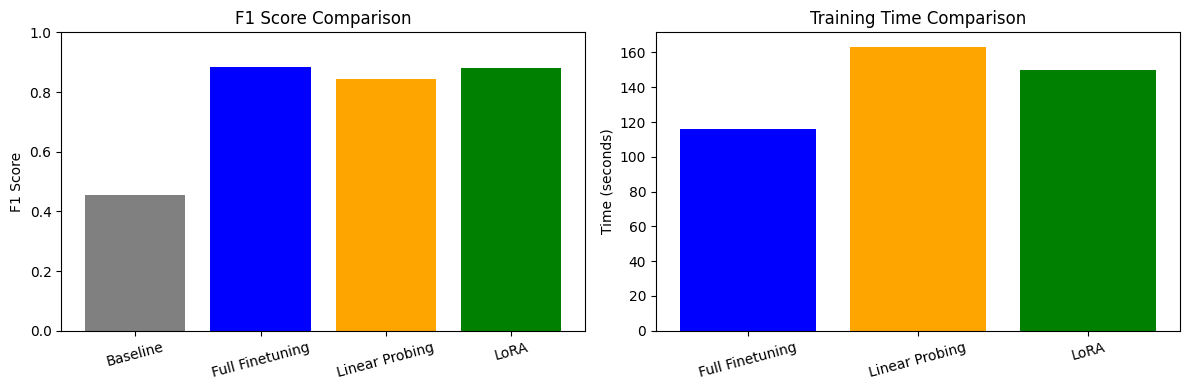

In [16]:
# визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = df_results['Method']
x = range(len(methods))

# график F1 Score
axes[0].bar(x, df_results['F1'], color=['gray', 'blue', 'orange', 'green'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score Comparison')
axes[0].set_ylim(0, 1)

# график времени обучения (без baseline)
axes[1].bar(x[1:], df_results['Time (s)'][1:], color=['blue', 'orange', 'green'])
axes[1].set_xticks(x[1:])
axes[1].set_xticklabels(methods[1:], rotation=15)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time Comparison')

plt.tight_layout()
plt.show()

## Выводы

### результаты сравнения методов

| Метод | F1 Score | Accuracy | Время | Параметры |
|-------|----------|----------|-------|-----------|
| Baseline | 0.456 | 41.8% | - | 0 |
| **Full Finetuning** | **0.885** | **88.4%** | 116s | ~67M (100%) |
| Linear Probing | 0.843 | 84.0% | 163s | ~592K (0.88%) |
| LoRA | 0.882 | 88.0% | 150s | ~740K (1.09%) |

### анализ

1. **Baseline** (~46% F1) — как и ожидалось, близко к случайному угадыванию. Классификационная голова инициализирована случайно и не обучена.

2. **Full Finetuning** — лучший результат (F1=0.885) и при этом самый быстрый из обученных методов. Парадокс в том, что хотя обучается больше параметров, сходимость происходит за меньше эпох. На практике full finetuning остается gold standard когда ресурсов достаточно.

3. **Linear Probing** — худший результат среди обученных моделей (F1=0.843) и самый долгий. Причина: замороженные эмбеддинги не могут адаптироваться под задачу, а маленький классификатор требует много эпох для обучения. Этот метод полезен только когда нужно очень быстро попробовать модель или когда данных мало и есть риск переобучения.

4. **LoRA** — отличный компромисс: качество почти как у full finetuning (0.882 vs 0.885), но обучается только ~1% параметров. На GPU преимущество было бы заметнее — меньше памяти, быстрее бэкпроп. LoRA особенно полезен для больших моделей (7B+), где full finetuning невозможен из-за ограничений памяти.

### что можно улучшить

- использовать весь датасет (50k примеров) для более репрезентативных результатов
- попробовать другие модели (RoBERTa, BERT-base)
- поэкспериментировать с гиперпараметрами LoRA (rank, alpha)
- добавить early stopping для автоматической остановки при переобучении
- использовать learning rate scheduler (cosine, linear warmup)

